In [7]:
#Apriori 알고리즘
from mlxtend.frequent_patterns import apriori, association_rules

# 연관분석용 데이터 파일 변환
from mlxtend.preprocessing import TransactionEncoder
import pandas as pd
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [5]:
#장바구니 데이터
tran = [
    ['A', 'B', 'C', 'D', 'E'],
    ['B', 'C'],
    ['A','B','F'],
    ['A','B','G'],
    ['A','F','H'],
]

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [9]:
#데이터 세트를 연관분석이 가능한 배열로 변환
te = TransactionEncoder()
tran_ar = te.fit(tran).transform(tran)
print(tran_ar)

#열 이름
print(te.columns_)

[[ True  True  True  True  True False False False]
 [False  True  True False False False False False]
 [ True  True False False False  True False False]
 [ True  True False False False False  True False]
 [ True False False False False  True False  True]]
['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H']


In [11]:
# 데이터프레임 변환
df = pd.DataFrame(tran_ar, columns=te.columns_)
df

,A,B,C,D,E,F,G,H
0,True,True,True,True,True,False,False,False
1,False,True,True,False,False,False,False,False
2,True,True,False,False,False,True,False,False
3,True,True,False,False,False,False,True,False
4,True,False,False,False,False,True,False,True


In [14]:
#각 상품별 거래 빈도
freq = df.sum().to_frame('Frequency')
# 빈도 역순으로 정렬
freq_sort = freq.sort_values('Frequency', ascending=False)
freq_sort

,Frequency
A,4
B,4
C,2
F,2
D,1
E,1
G,1
H,1


In [15]:
# 지지도
freq_sort['Support'] = freq_sort['Frequency'] / len(tran)
freq_sort

,Frequency,Support
A,4,0.8
B,4,0.8
C,2,0.4
F,2,0.4
D,1,0.2
E,1,0.2
G,1,0.2
H,1,0.2


<Axes: title={'center': 'Frequent Items'}>

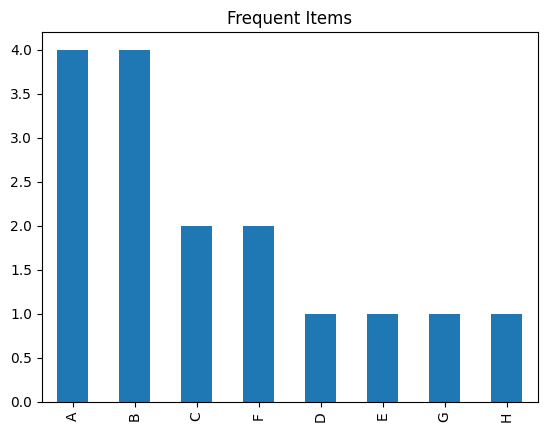

In [17]:
# 상품아이템별 거래 빈도
freq_sort['Frequency'].plot(kind='bar', title="Frequent Items")

<Axes: >

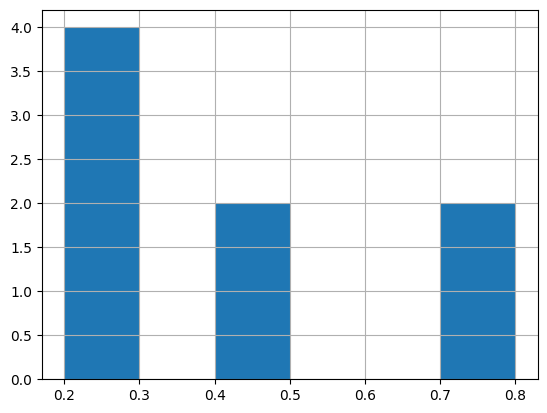

In [19]:
# 상품 아이템 지지도의 히스토그램
freq_sort['Support'].hist(bins=6)

In [21]:
# 빈발항목과 지지도
freq_items = apriori(df, min_support=0.4,use_colnames = True)
freq_items

,support,itemsets
0,0.8,(A)
1,0.8,(B)
2,0.4,(C)
3,0.4,(F)
4,0.6,"(B, A)"
5,0.4,"(A, F)"
6,0.4,"(B, C)"


In [23]:
# 연관 규칙
rules = association_rules(freq_items,
          metric="confidence",min_threshold=0.7)
rules

# 조건절 -> 종속절 || 조건부 => 결론부

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(B),(A),0.8,0.8,0.6,0.75,0.9375,1.0,-0.04,0.8,-0.250000,0.6,-0.25,0.75
1,(A),(B),0.8,0.8,0.6,0.75,0.9375,1.0,-0.04,0.8,-0.250000,0.6,-0.25,0.75
2,(F),(A),0.4,0.8,0.4,1.00,1.2500,1.0,0.08,inf,0.333333,0.5,1.00,0.75
3,(C),(B),0.4,0.8,0.4,1.00,1.2500,1.0,0.08,inf,0.333333,0.5,1.00,0.75


In [27]:
# rules['lift'] > 1

# 리프트가 1보다 큰 규칙
rules = rules[(rules['lift'] > 1)]
# 신뢰도의 내림차순 정렬
rules.sort_values(by='confidence', ascending=False)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
2,(F),(A),0.4,0.8,0.4,1.0,1.25,1.0,0.08,inf,0.333333,0.5,1.0,0.75
3,(C),(B),0.4,0.8,0.4,1.0,1.25,1.0,0.08,inf,0.333333,0.5,1.0,0.75


In [30]:
# 조건부에 'F'가 있는 규칙
rules[rules.antecedents.apply(lambda x: 'F' in x)]


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
2,(F),(A),0.4,0.8,0.4,1.0,1.25,1.0,0.08,inf,0.333333,0.5,1.0,0.75


In [31]:
# 결론부에 'B'가 있는 규칙
rules[rules.consequents.apply(lambda x: 'B' in x)]


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
3,(C),(B),0.4,0.8,0.4,1.0,1.25,1.0,0.08,inf,0.333333,0.5,1.0,0.75
